In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import sys

sys.path.append('..')

from src.models import PollutionSVModel
from src.backtest import StraddleBacktest, StressTest, RegimeSwitchingBacktest, DeltaNeutralStrangleBacktest

In [2]:
from pathlib import Path

ROOT = Path('..').resolve()

In [3]:
df = pd.read_csv(ROOT / 'data' / 'csi300_pollution_s2_df.csv', index_col='Date', parse_dates=True)

In [4]:
sv = PollutionSVModel(
    sigma     = df['realized_vol'],
    pollution = df['pm25'],
    dt        = 1/252
)

sv.fit(delta_init=0.0029)


  Straddle Backtest — Pollution Signal
  Signal : PM2.5 > rolling mean + 1σ (60d)
  Hold   : 5 days | Cost: 10.0bps
  N trades             175
  Win rate             0.4914
  Mean P&L             1.7273
  Std P&L              60.3352
  Sharpe               0.2032
  Max drawdown         520.943
  Calmar               0.1671
  Total P&L            302.2771



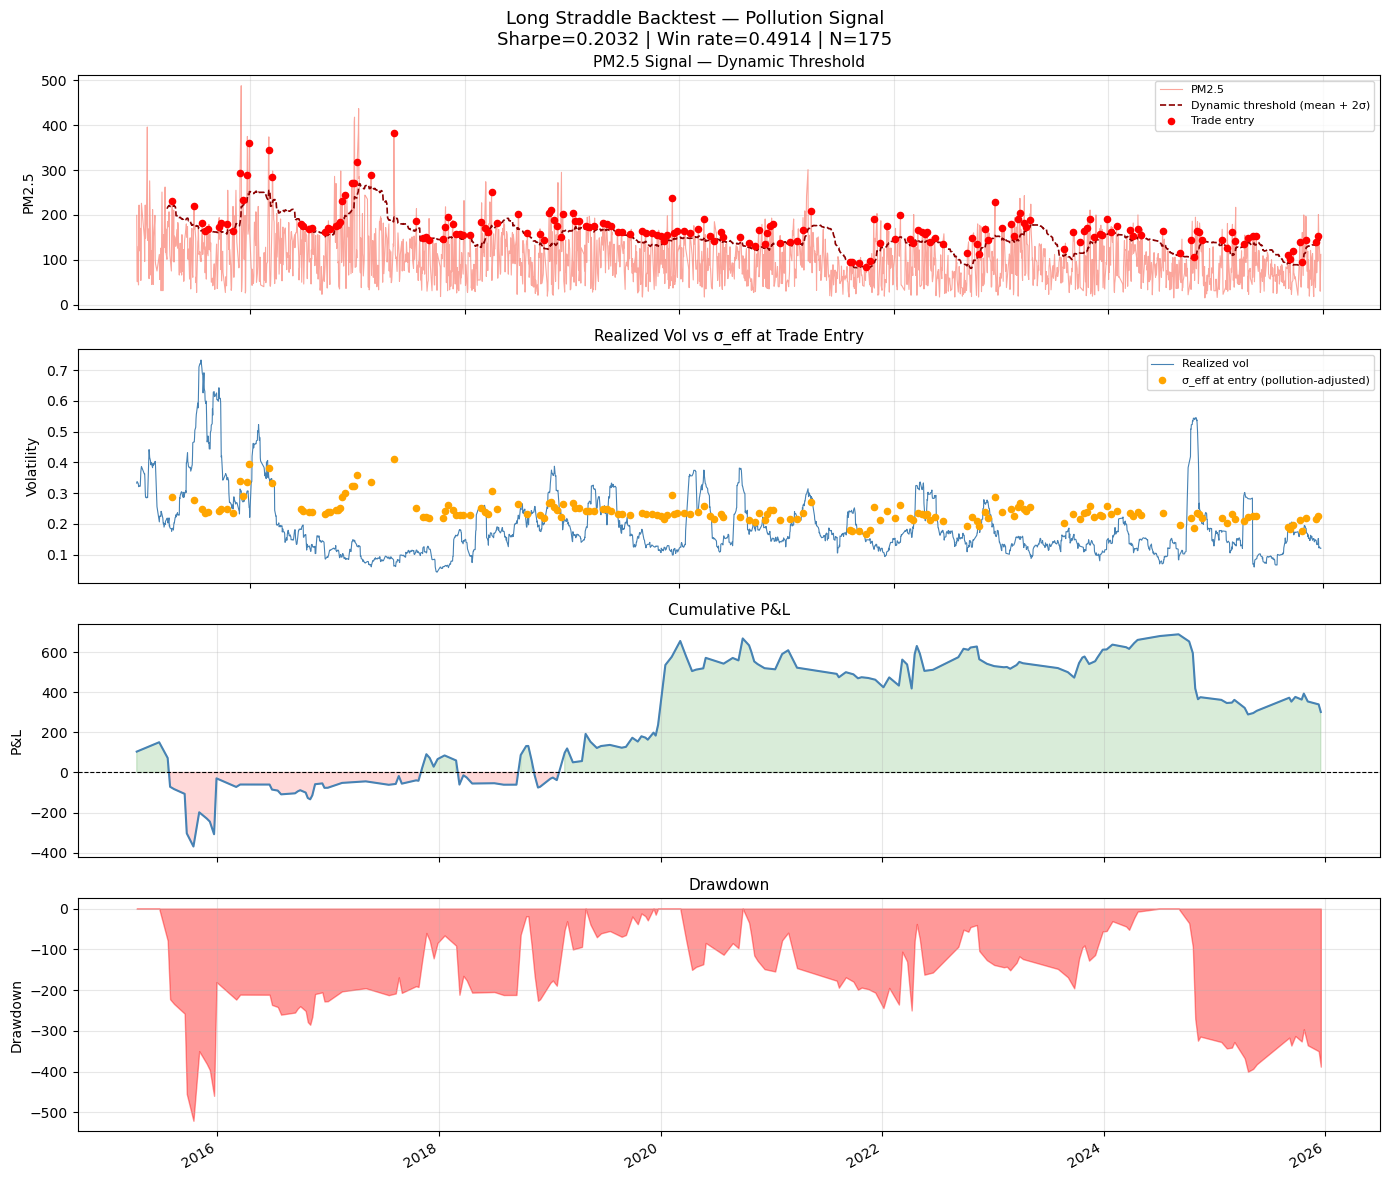

In [5]:
bt = StraddleBacktest(
    df            = df,
    sv_model      = sv,
    signal_window = 60,    # 3 months for the moving threshold
    holding_days  = 5,     # hold 1 week
    cost_bps      = 10,    # 10bps aller-retour
    r             = 0.03,
    T_option      = 1/12   # options 1 month
)

bt.run()
bt.summary()
bt.plot()


── Pollution Regime Analysis ──
                    N trades  Win rate  Sharpe  Mean P&L  Max drawdown
Regime                                                                
Low PM2.5 (< 70)          31    0.6774  1.9599  145.4108      286.3969
Mid PM2.5 (70–121)        32    0.6562  1.4509   83.0699      516.8790
High PM2.5 (> 121)        24    0.5833  1.3084  107.4174      395.9955


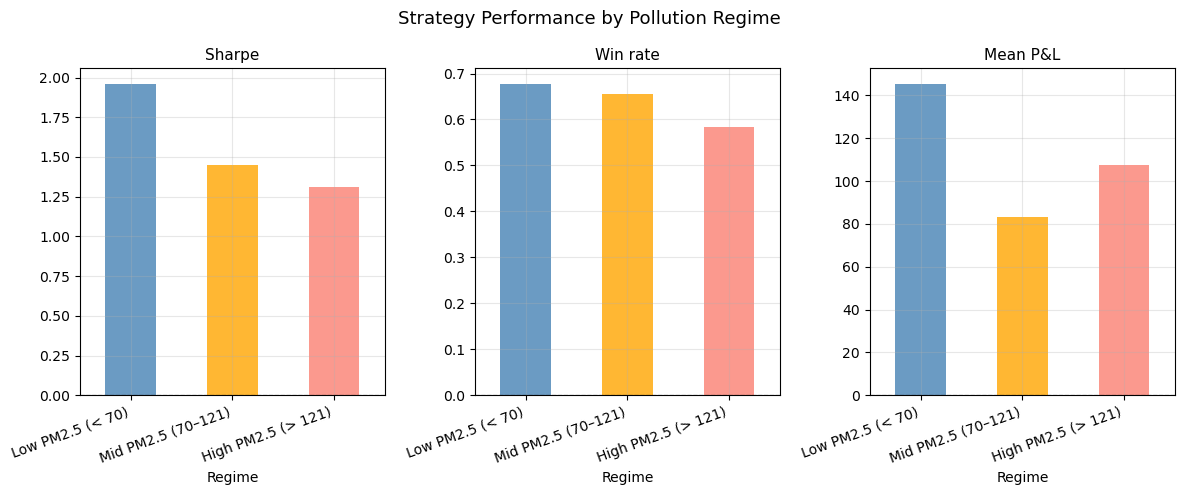


── Vol Regime Analysis ──
                     N trades  Win rate  Sharpe  Mean P&L  Max drawdown
Regime                                                                 
Low vol (< 0.14)           25    0.6800  1.4499  104.3372       98.6947
Mid vol (0.14–0.19)        24    0.5833  1.8019  110.1738      228.7286
High vol (> 0.19)          26    0.5769  1.2333   93.6883      402.7767


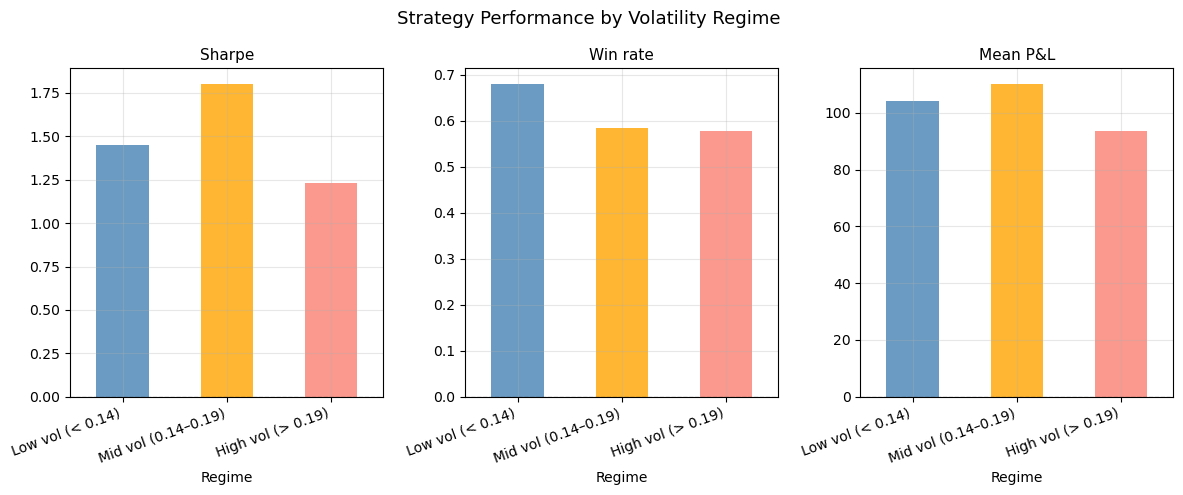


── Crash Period Analysis ──
                N trades  Win rate  Sharpe  Mean P&L  Max drawdown
Regime                                                            
Crash periods         15    0.5333  1.1961  123.6117      274.1200
Normal periods        62    0.4355  0.2624   11.5933      716.9329

── Walk-Forward Analysis (by year) ──
      N trades  Win rate  Sharpe  Mean P&L
Year                                      
2015         4    0.7500  2.4313  108.6627
2016         5    0.6000  1.6877   30.1462
2017         5    0.8000  1.0516   18.8751
2018         6    0.0000 -4.3564  -88.6862
2019         6    0.5000  0.8792   28.0980
2020         6    0.3333 -0.8552  -28.2689
2021         4    0.0000 -3.9217  -78.2775
2022         5    0.2000 -1.3240  -36.2094
2023         5    0.8000  2.9084   42.4392
2024         5    0.4000  0.4008   36.4084
2025         4    0.2500 -1.3471  -32.4805


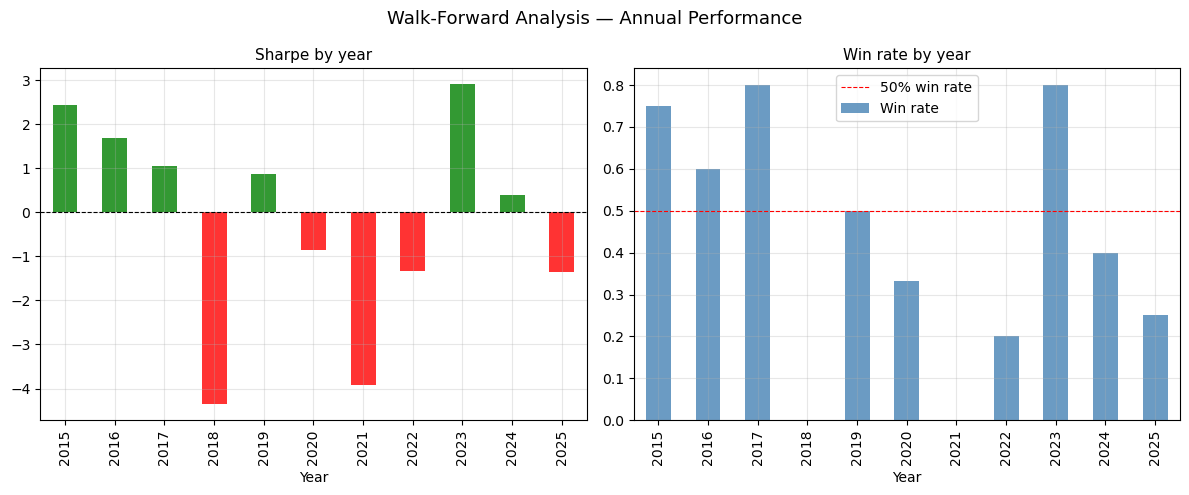

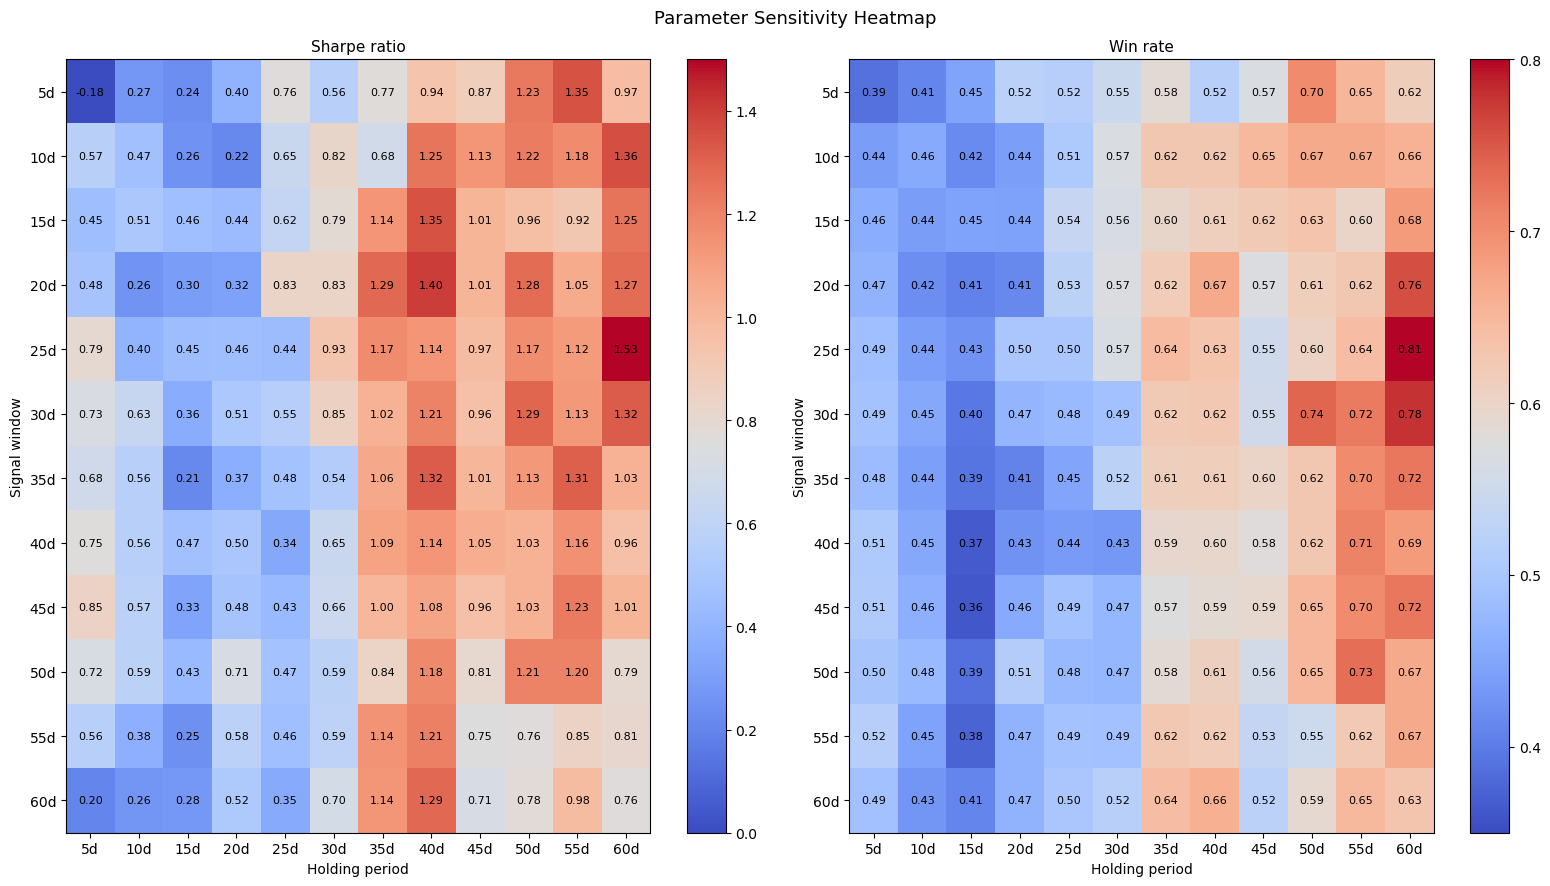

In [6]:
st = StressTest(df, sv)

pollution_results = st.test_pollution_regimes(holding_days=20)
vol_results       = st.test_vol_regimes(holding_days=20)
crash_results     = st.test_crash_periods(holding_days=20)
wf_results        = st.test_walk_forward(holding_days=20)
param_heatmap     = st.test_parameter_sensitivity(
    windows  = range(5, 61, 5),
    holdings = range(5, 61, 5)
)


  Straddle Backtest — Pollution Signal
  Signal : PM2.5 > rolling mean + 1σ (25d)
  Hold   : 60 days | Cost: 10.0bps
  N trades             37
  Win rate             0.8108
  Mean P&L             197.7095
  Std P&L              265.156
  Sharpe               1.5281
  Max drawdown         411.9499
  Calmar               2.0157
  Total P&L            7315.2508



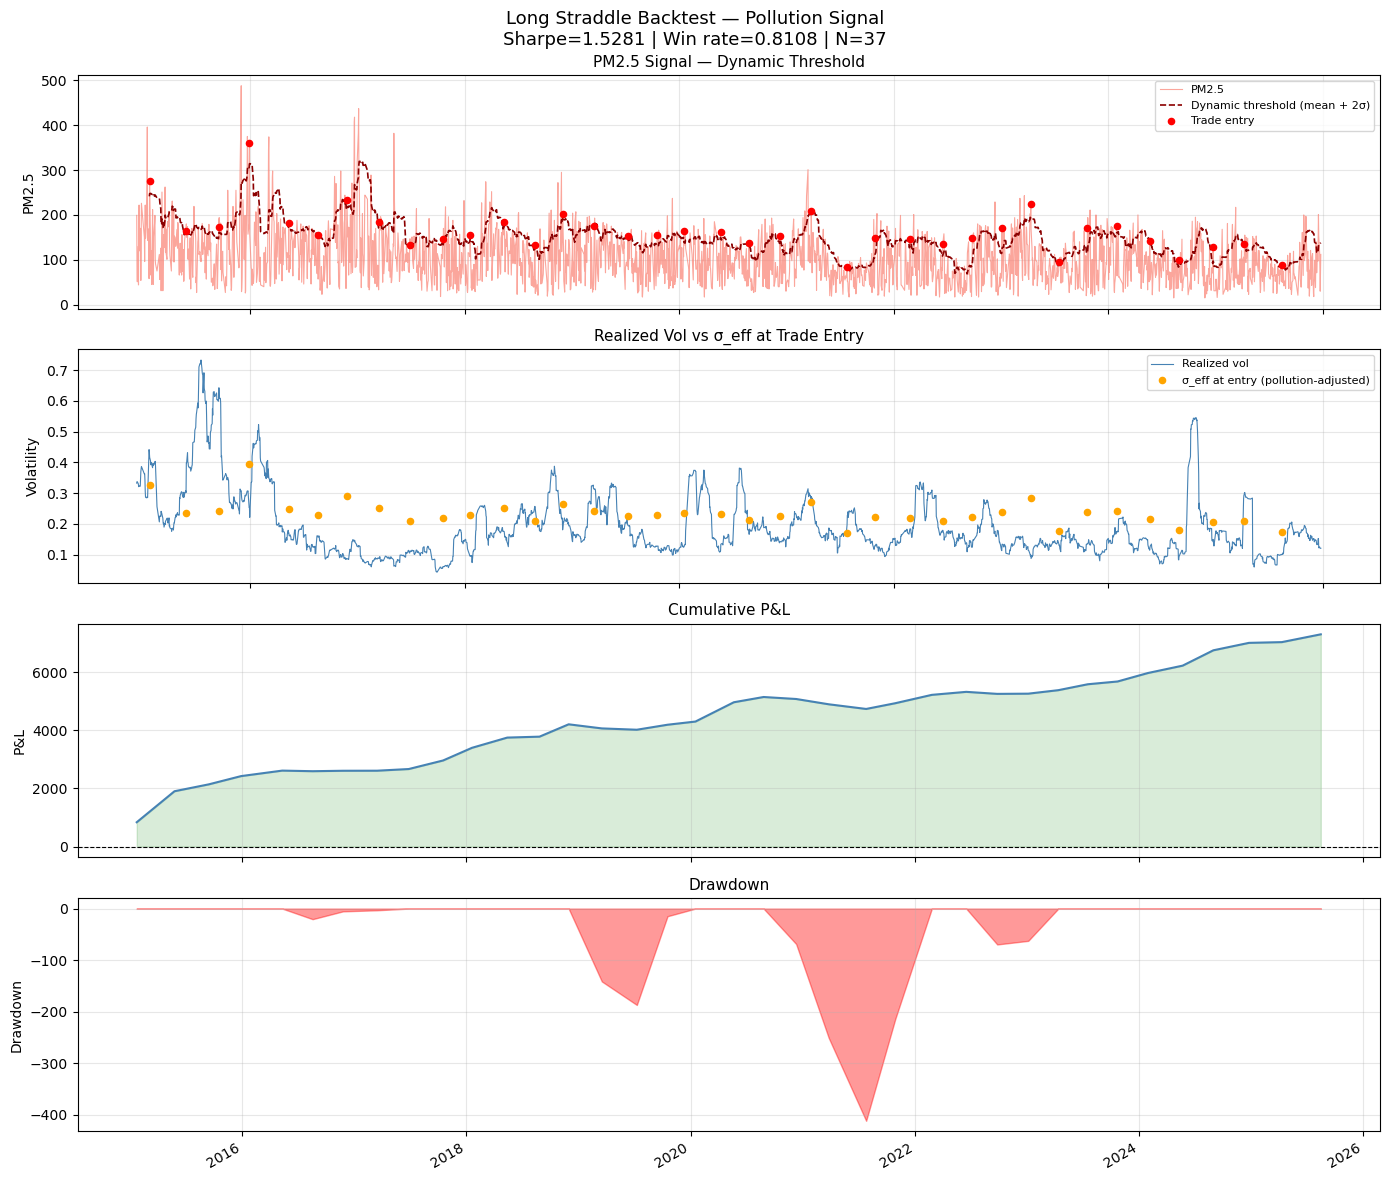

In [7]:
bt = StraddleBacktest(
    df            = df,
    sv_model      = sv,
    signal_window = 25,    # 3 months for the moving threshold
    holding_days  = 60,     # hold 1 week
    cost_bps      = 10,    # 10bps aller-retour
    r             = 0.03,
    T_option      = 1/12   # options 1 month
)

bt.run()
bt.summary()
bt.plot()


  Regime-Switching Backtest
  Long vol : PM2.5 > mean+2σ | Short vol : PM2.5 < mean-2σ
  Window=25d | Hold=60d
  N trades               26
  N long vol             20
  N short vol            6
  Win rate               0.6154
  WR long vol            0.65
  WR short vol           0.5
  Mean P&L               179.1916
  Sharpe                 0.9676
  Max drawdown           193.1538
  Total P&L              4658.9829



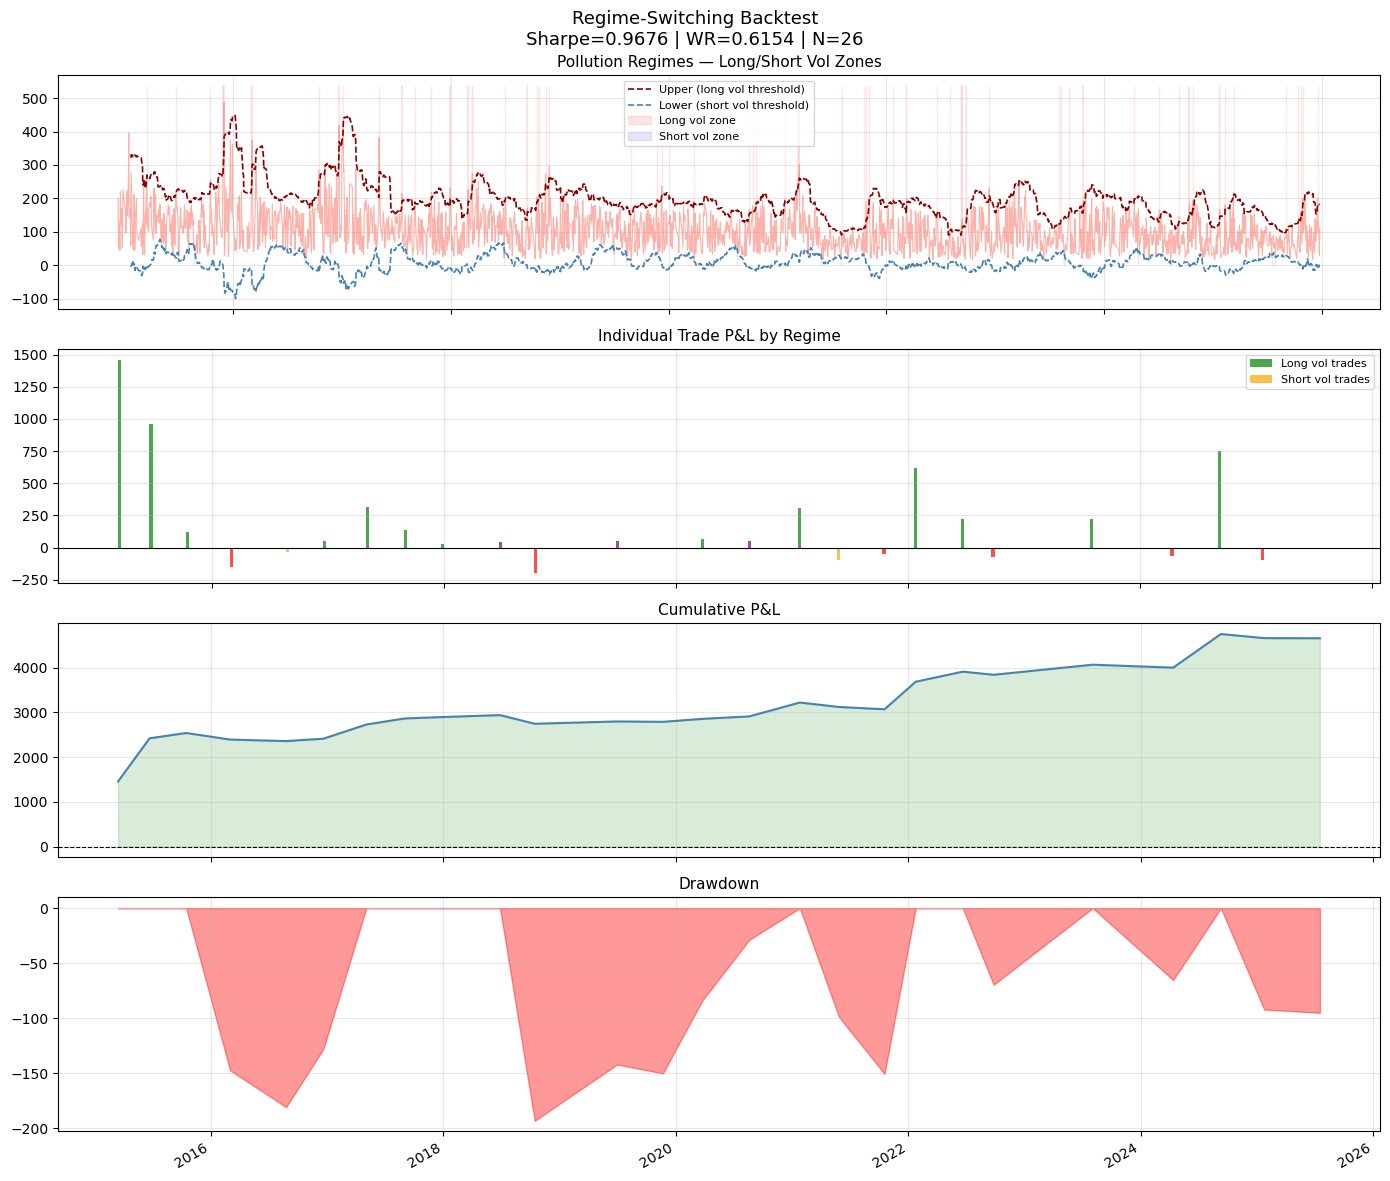

In [8]:
# ── Regime switching ──────────────────────────────────────────────
rs = RegimeSwitchingBacktest(
    df            = df,
    sv_model      = sv,
    signal_window = 25,
    holding_days  = 60,
    short_width   = 0.05,   # 5% OTM for the short strangle
    stop_loss_mult= 2.0,    # stop at 2× the premium received
)
rs.run()
rs.summary()
rs.plot()


  Delta-Neutral Strangle Backtest
  Width=5% OTM | Window=25d | Hold=60d
  N trades                  37
  Win rate                  0.8649
  Mean P&L                  73.5243
  Mean option PnL           146.3117
  Mean hedge PnL            -69.5958
  Mean hedge cost           3.145
  Sharpe                    1.6688
  Max drawdown              202.872
  Total P&L                 2720.3985



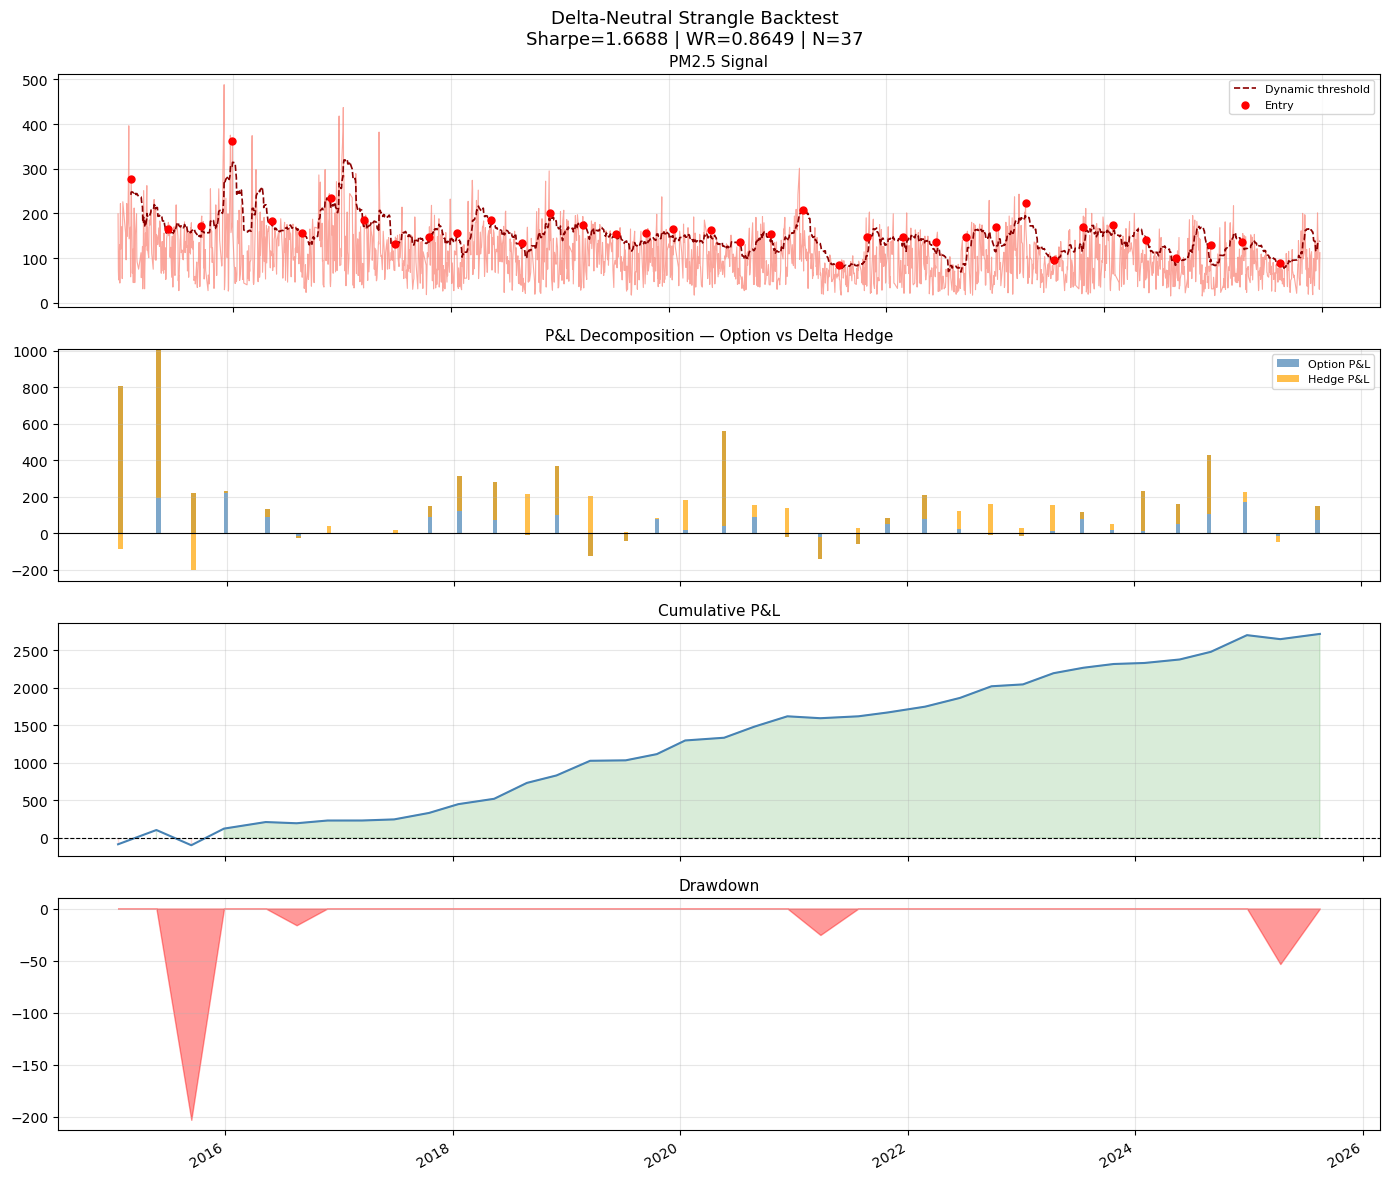

In [9]:
# ── Delta-neutral strangle ────────────────────────────────────────
dns = DeltaNeutralStrangleBacktest(
    df            = df,
    sv_model      = sv,
    signal_window = 25,
    holding_days  = 60,
    width         = 0.05,   # 5% OTM
    cost_bps      = 10,
    hedge_cost_bps= 2,      # cost of daily rebalancing
)
dns.run()
dns.summary()
dns.plot()